# Análisis de costes de seguros médicos — Curso 0 Python (Máster en Ciencias Actuariales, UC3M)

Este notebook es donde se desarrolla y documenta el análisis. **No define funciones**: importa las de
`scripts/funciones.py` (que son genéricas y reutilizables) y las aplica a nuestros datos.

Estructura del notebook:
1. Parámetros e imports
2. Descarga de los datos desde GitHub y carga en la base de datos
3. Exploración inicial
4. Histogramas
5. Asociación entre ser fumador y no tener hijos
6. Guardar los gráficos en un PDF
7. Conclusiones

## 1. Parámetros e imports

Todo lo que depende de *este* proyecto concreto (la URL de los datos, las rutas, el nombre de la tabla)
se define aquí arriba como parámetros. Las funciones reciben estos valores como argumentos, así que para
usarlas con otra base de datos solo habría que cambiar esta celda.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Carpeta raíz del proyecto: funciona tanto si Jupyter arranca en notebooks/ como en la raíz
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  # para poder hacer "from scripts.funciones import ..."

from scripts.funciones import (
    descargar_csv, cargar_csv_en_db, leer_tabla,
    histograma, guardar_figuras_pdf,
    tabla_contingencia, test_asociacion, resumen_asociacion,
)

# ---- Parámetros del análisis ----
URL_DATOS = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
DATA_DIR = PROJECT_ROOT / "data"
RUTA_CSV = DATA_DIR / "seguros.csv"
RUTA_DB = DATA_DIR / "proyecto.db"
TABLA = "seguros"
RUTA_PDF = DATA_DIR / "graficos.pdf"

## 2. Descarga de los datos y carga en la base de datos

Usamos el dataset público *Medical Cost Personal Datasets* (1.338 asegurados), alojado en GitHub.

- `descargar_csv(url, ruta_destino)` lo descarga y guarda una copia en `data/`.
- `cargar_csv_en_db(ruta_csv, ruta_db, nombre_tabla)` lo guarda como tabla en la base de datos SQLite.

Si no hay conexión a internet, se usa la copia local que ya está en el repositorio.

In [2]:
try:
    descargar_csv(URL_DATOS, RUTA_CSV)
    print(f"Datos descargados de GitHub y guardados en {RUTA_CSV.relative_to(PROJECT_ROOT)}")
except Exception as error:
    print(f"No se pudo descargar ({error.__class__.__name__}); se usa la copia local {RUTA_CSV.relative_to(PROJECT_ROOT)}")

n_filas = cargar_csv_en_db(RUTA_CSV, RUTA_DB, TABLA)
print(f"Tabla '{TABLA}' cargada en la base de datos con {n_filas} filas")

Datos descargados de GitHub y guardados en data\seguros.csv
Tabla 'seguros' cargada en la base de datos con 1338 filas


## 3. Exploración inicial

Leemos la tabla desde la base de datos con `leer_tabla()` y echamos un primer vistazo.

In [3]:
df = leer_tabla(RUTA_DB, TABLA)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 4. Histogramas

`histograma(datos, ancho_banda, titulo)` recibe **cualquier columna numérica** y devuelve la figura sin
mostrarla ni guardarla. Así podemos reutilizar la misma función para varias variables. Guardamos todas las
figuras en una lista para juntarlas después en un PDF.

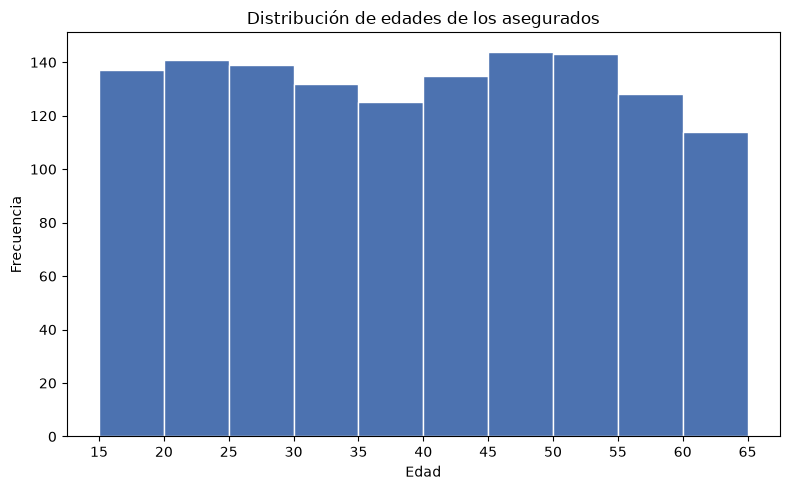

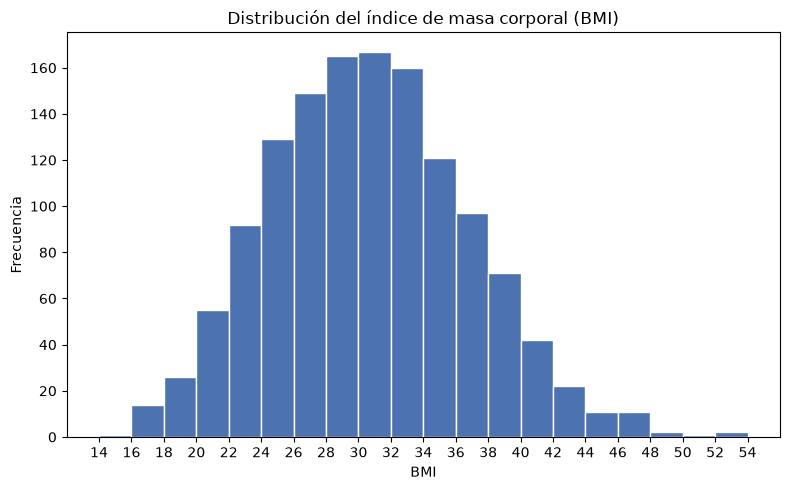

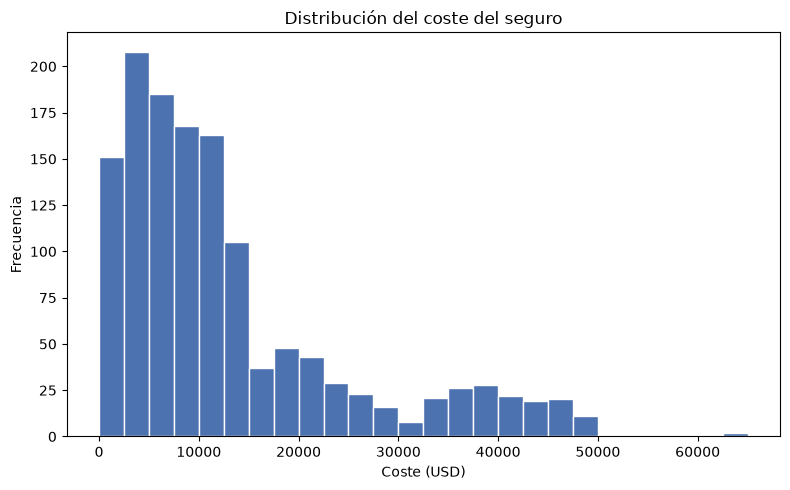

In [5]:
figuras = []

fig, ax = histograma(df["age"], ancho_banda=5, titulo="Distribución de edades de los asegurados", etiqueta_x="Edad")
figuras.append(fig)

fig, ax = histograma(df["bmi"], ancho_banda=2, titulo="Distribución del índice de masa corporal (BMI)", etiqueta_x="BMI")
figuras.append(fig)

fig, ax = histograma(df["charges"], ancho_banda=2500, titulo="Distribución del coste del seguro", etiqueta_x="Coste (USD)")
figuras.append(fig)

plt.show()

## 5. Asociación entre ser fumador y no tener hijos

**Pregunta:** ¿las personas sin hijos fuman más (o menos) que las que tienen hijos?

### 5.1 Preparar las variables

Las dos variables que queremos relacionar son **categóricas**, no numéricas, así que las convertimos a binario (1 = sí, 0 = no):
- `fumador` = 1 si `smoker == "yes"`
- `sin_hijos` = 1 si `children == 0`

Esta transformación es propia de *este* análisis, por eso se hace aquí en el notebook y no en el script.

In [6]:
df["fumador"] = (df["smoker"] == "yes").astype(int)
df["sin_hijos"] = (df["children"] == 0).astype(int)
df[["smoker", "children", "fumador", "sin_hijos"]].head()

,smoker,children,fumador,sin_hijos
0,yes,0,1,1
1,no,1,0,0
2,no,3,0,0
3,no,0,0,1
4,no,0,0,1


### 5.2 ¿Por qué una tabla de contingencia (`pd.crosstab`)?

Con variables categóricas no tiene sentido hacer cuentas con los valores (no hay una "media de fumar"). Lo que
sí podemos estudiar es **cuántas personas caen en cada combinación de categorías**. Eso es exactamente una
tabla de contingencia, y `pd.crosstab` la construye contando las filas del DataFrame:

|                 | con hijos (0) | sin hijos (1) |
|-----------------|---------------|---------------|
| no fumador (0)  | a             | b             |
| fumador (1)     | c             | d             |

La necesitamos porque:
1. **El test chi-cuadrado trabaja sobre frecuencias, no sobre las filas originales.** `chi2_contingency` compara
   los recuentos observados en cada casilla con los que esperaríamos si las dos variables fueran independientes.
   Si la diferencia es grande, rechazamos la independencia.
2. **El coeficiente phi se calcula a partir de las cuatro casillas:**
   $\phi = \dfrac{ad - bc}{\sqrt{(a+b)(c+d)(a+c)(b+d)}}$.
   Phi es la correlación de Pearson aplicada a dos variables 0/1 y va de −1 a 1: cerca de 0 indica que no hay relación.
3. Además, permite **ver los datos**: antes de calcular nada ya se aprecia si las proporciones son parecidas o no.

Primero miramos la tabla con `tabla_contingencia()`:

In [7]:
tabla = tabla_contingencia(df, "fumador", "sin_hijos")
tabla

sin_hijos,0,1
fumador,,
0,605,459
1,159,115


Para comparar mejor, vemos la proporción de fumadores dentro de cada grupo (con y sin hijos):

In [8]:
(tabla / tabla.sum()).round(3)

sin_hijos,0,1
fumador,,
0,0.792,0.8
1,0.208,0.2


### 5.3 Test chi-cuadrado y coeficiente phi

`test_asociacion(df, var1, var2)` construye la tabla de contingencia, aplica el test chi-cuadrado
(H0: las variables son independientes) y calcula phi. Lo aplicamos a todos los asegurados y, filtrando
el DataFrame en el notebook, por separado a mujeres y hombres.

In [9]:
grupos = {
    "Todos": df,
    "Mujeres": df[df["sex"] == "female"],
    "Hombres": df[df["sex"] == "male"],
}

resultados = {nombre: test_asociacion(datos, "fumador", "sin_hijos") for nombre, datos in grupos.items()}

resumen = pd.DataFrame({nombre: resumen_asociacion(r) for nombre, r in resultados.items()}).T
resumen

,n,phi,chi2,p_valor,asociacion_significativa
Todos,1338,-0.009526,0.078399,0.779479,False
Mujeres,662,0.022478,0.225555,0.634839,False
Hombres,676,-0.035556,0.693264,0.405057,False


Comprobación: phi coincide con la correlación de Pearson calculada directamente sobre las columnas 0/1.

In [10]:
print(f"phi desde la tabla de contingencia: {resultados['Todos']['phi']:.4f}")
print(f"Pearson con df.corr():              {df['fumador'].corr(df['sin_hijos']):.4f}")

phi desde la tabla de contingencia: -0.0095
Pearson con df.corr():              -0.0095


## 6. Guardar los gráficos en un PDF

Con `guardar_figuras_pdf()` juntamos todas las figuras en un único PDF (una por página) dentro de `data/`,
para tener los resultados organizados y poder revisarlos después.

In [11]:
ruta = guardar_figuras_pdf(figuras, RUTA_PDF)
print(f"{len(figuras)} gráficos guardados en {ruta.relative_to(PROJECT_ROOT)}")

3 gráficos guardados en data\graficos.pdf


## 7. Conclusiones

- La proporción de fumadores es prácticamente la misma entre quienes tienen hijos y quienes no.
- El coeficiente phi es muy cercano a 0 en los tres grupos (todos, mujeres y hombres) y los p-valores del
  test chi-cuadrado son muy superiores a 0,05: **no hay evidencia de asociación entre ser fumador y no tener hijos**,
  ni en general ni al separar por sexo.
- Para un actuario esto indica que, en esta cartera, tener o no hijos no sirve como indicador del riesgo
  "fumador", que es la variable que más encarece el seguro.